## 🛠️ 0. Colab Environment Setup
Run once per Colab session. Installs pinned PyTorch + Mamba2 wheels and mounts your Drive.


In [ ]:
# Uninstall conflicting Colab defaults
!pip uninstall -y transformers sentence-transformers torch torchvision torchaudio

# Install pinned PyTorch cu121 (must match Mamba wheel builds)
!pip install torch==2.4.0 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install transformers==4.39.3 packaging triton==3.0.0

# Pre-built Mamba2 wheels (saves 20-30 min vs compiling from source)
!wget -qO causal_conv1d-1.4.0-cp312-cp312-linux_x86_64.whl "https://github.com/Dao-AILab/causal-conv1d/releases/download/v1.4.0/causal_conv1d-1.4.0%2Bcu122torch2.4cxx11abiFALSE-cp312-cp312-linux_x86_64.whl"
!wget -qO mamba_ssm-2.2.4-cp312-cp312-linux_x86_64.whl "https://github.com/state-spaces/mamba/releases/download/v2.2.4/mamba_ssm-2.2.4%2Bcu12torch2.4cxx11abiFALSE-cp312-cp312-linux_x86_64.whl"
!pip install causal_conv1d-1.4.0-cp312-cp312-linux_x86_64.whl
!pip install mamba_ssm-2.2.4-cp312-cp312-linux_x86_64.whl

# Scientific stack
!pip install yfinance gluonts tqdm utilsforecast pyyaml pandas numpy submitit torchmetrics gpytorch statsforecast properscoring

Found existing installation: transformers 5.0.0
Uninstalling transformers-5.0.0:
  Successfully uninstalled transformers-5.0.0
Found existing installation: sentence-transformers 5.2.3
Uninstalling sentence-transformers-5.2.3:
  Successfully uninstalled sentence-transformers-5.2.3
Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 799.0/799.0 MB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 106.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 96.2 MB/s eta 0:00:00
     ━

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!git clone https://github.com/ngngsonan/SC-Mamba.git /content/SC-Mamba 2>/dev/null || echo 'Repo already cloned'

%cd /content/SC-Mamba
!git pull


Mounted at /content/drive
/content/SC-Mamba
Already up to date.


In [ ]:
import os, sys
# ── Critical env vars for Triton 3.x on T4/A100 ─────────────────────────────
# TRITON_F32_DEFAULT=ieee prevents IndexError: map::at on Turing GPUs.
# Must be set BEFORE any mamba_ssm or triton import.
os.environ['TRITON_F32_DEFAULT'] = 'ieee'
os.environ['SC_MAMBA_DIAG'] = '1'

PROJECT_ROOT = '/content/SC-Mamba'
CKPT_DIR = '/content/drive/MyDrive/Colab Notebooks/SCMamba/sc_mamba_checkpoints'

os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)
print(f"✅ CWD = {os.getcwd()}")

# Sanity-check key files
for path in ['core/train.py', 'core/models.py', 'core/real_data_val_pipeline.py', 'core/real_data_args.yaml']:
    status = "✅" if os.path.exists(path) else "❌ MISSING"
    print(f"  {status}  {path}")


✅ CWD = /content/SC-Mamba
  ✅  core/train.py
  ✅  core/models.py
  ✅  core/real_data_val_pipeline.py
  ✅  core/real_data_args.yaml


Device: cuda

 LOADING MODELS
  Multi model: N_assets=8
  Uni   model: N_assets=1


 PART 1: CAUSAL EXPLAINABILITY — SPECTRAL LAYER ANALYSIS

[1.1] Spectral Layer Learned Parameters:
  τ (causal threshold)  = 1.0179
  α (sigmoid sharpness) = 9.8556
  D_model               = 1024
  mask(k) = sigmoid(9.86 × (|F(k)| - 1.0179))

[1.2] Running real data through full pipeline with spectral hook...
  ✅ Hook captured

[1.3] Spectral Mask Diagnostics:
  Bin   Mean Mask     Max Mask      Mean |F|      Pass %    
  ----------------------------------------------------------
  0     0.042561      1.000000      0.3773           3.3%
  1     0.000064      0.000188      0.0365           0.0%
  2     0.000089      0.000523      0.0629           0.0%
  3     0.000070      0.000186      0.0439           0.0%
  4     0.000059      0.000099      0.0295           0.0%

  Overall mask pass rate: 0.7%

[1.4] Cross-Asset Correlation Analysis:

  ρ BEFORE spectral layer (backbone embeddings):
       AUD    GBP 

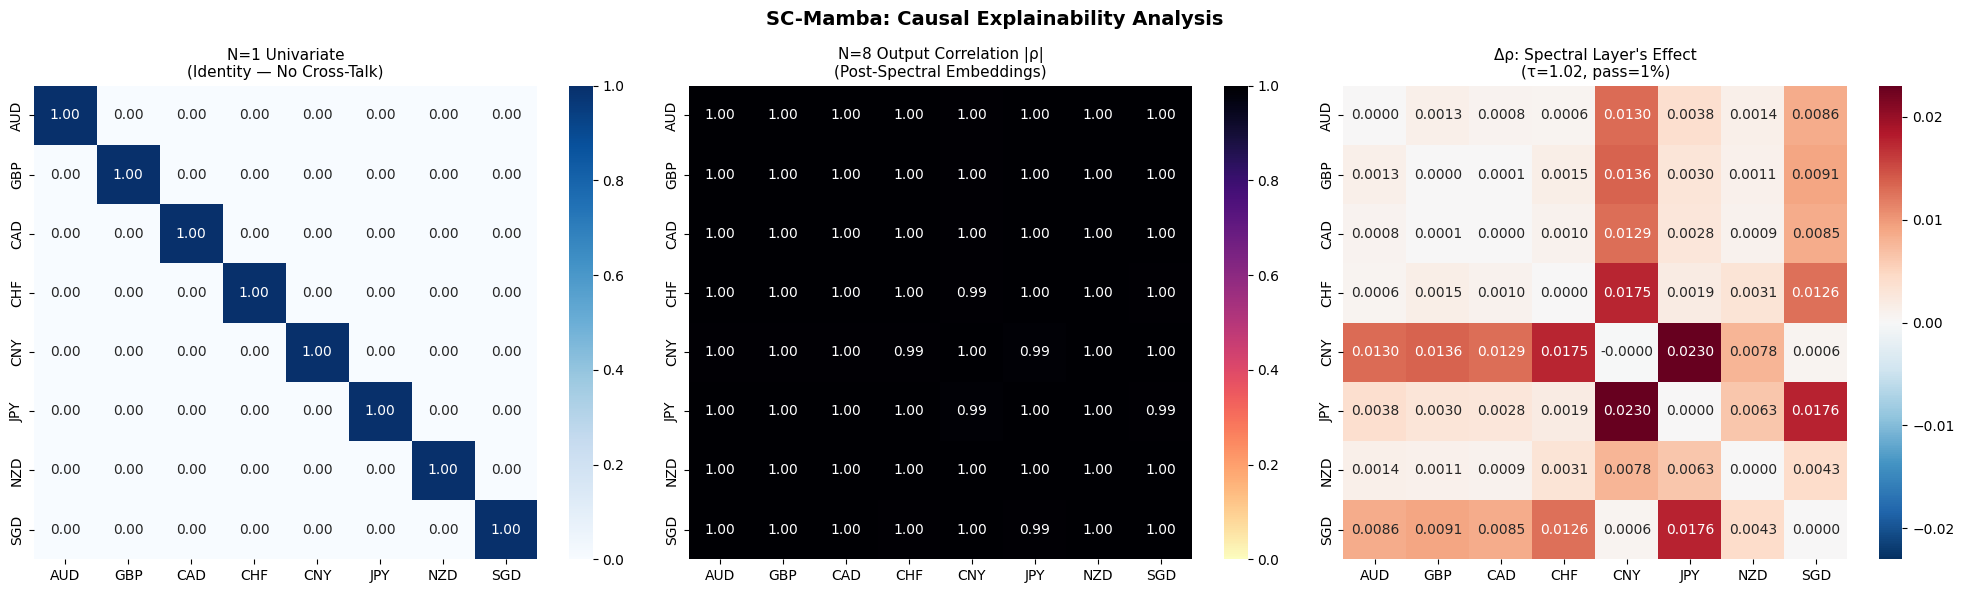

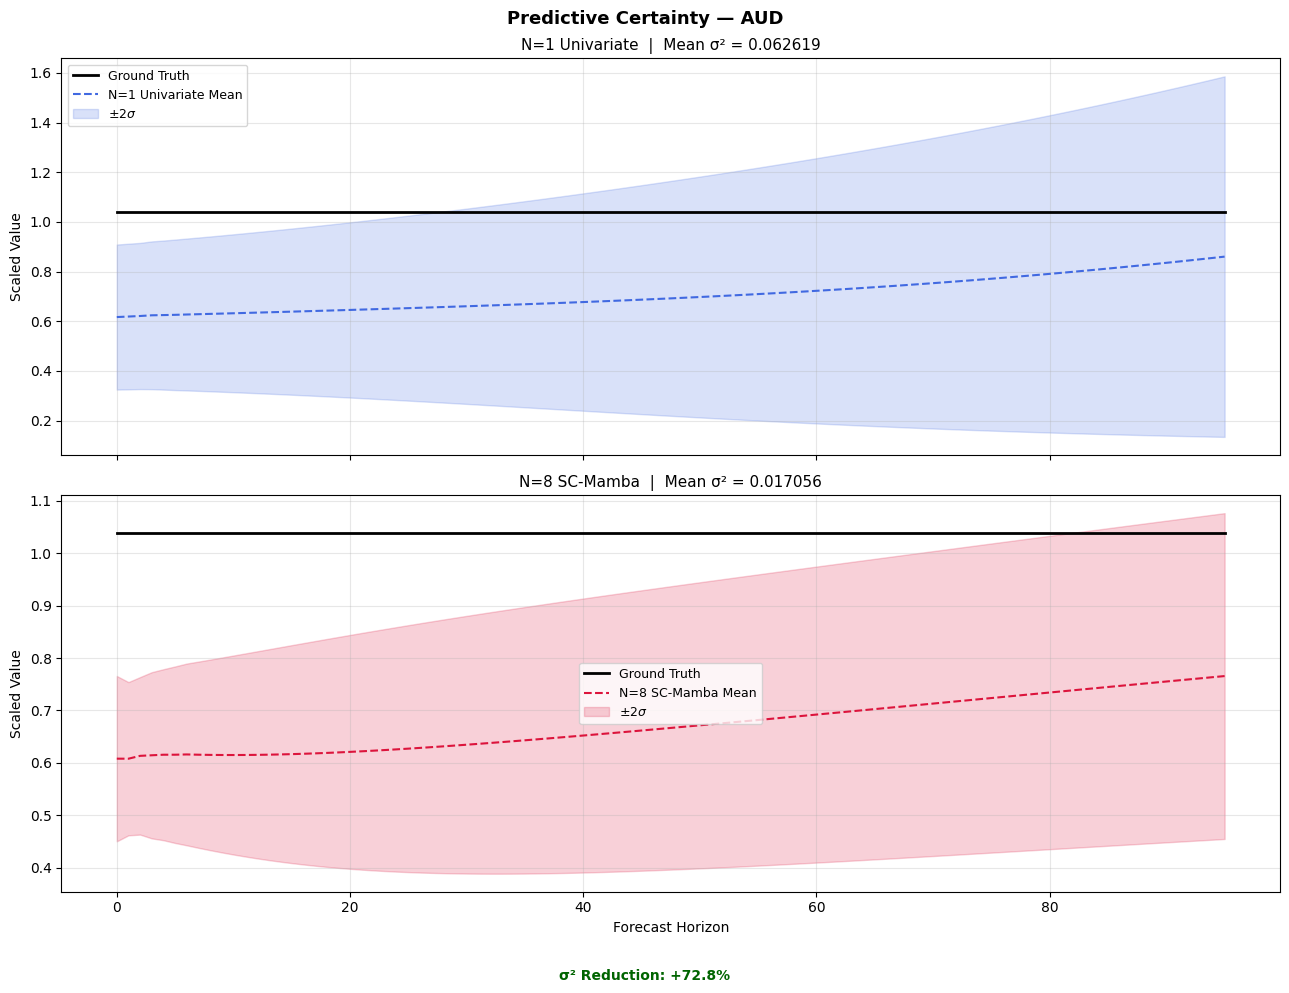

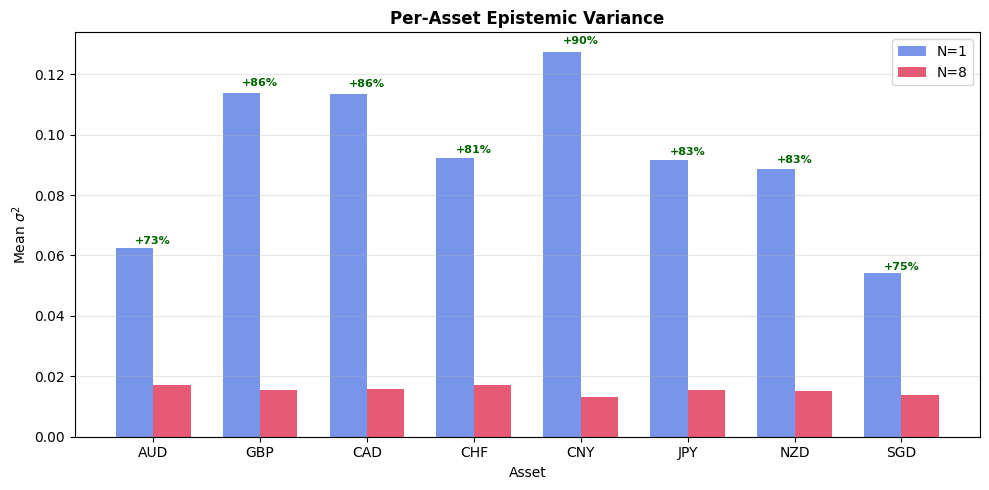

In [ ]:
"""
20_analysis_causal_explain.py — SC-Mamba Advantage Analysis
============================================================
Demonstrates the two core advantages of SC-Mamba over univariate baselines:
  PART 1: Causal Explainability — Spectral layer internal diagnostics.
  PART 2: Predictive Certainty  — Epistemic variance reduction (σ²).
  PART 3: Quantitative Ablation — Full metrics (MASE/MAE/RMSE/SMAPE/NLL/mCRPS)
           via the SAME canonical pipeline as 11_eval_ckp_crossAsset.py.

All numerical results are printed BEFORE plots.
Model input shapes verified against eval_real_dataset.py:386-395.
"""
import torch, os, sys, math
import torch.nn.functional as TF
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# ── Resolve project root ───────────────────────────────────────────────────
PROJECT_ROOT = '.'
if not os.path.exists(os.path.join(PROJECT_ROOT, 'core')):
    PROJECT_ROOT = '/content/SC-Mamba'
sys.path.insert(0, PROJECT_ROOT)
os.environ['TRITON_F32_DEFAULT'] = 'ieee'

from core.models import SCMamba_Forecaster
from core.real_data_val_pipeline import validate_on_real_dataset
from data.data_provider.multivariate_loader import MultivariateRealDataset

# ── Configuration ──────────────────────────────────────────────────────────
CKPT_MULTI = '/content/drive/MyDrive/Colab Notebooks/SCMamba/sc_mamba_checkpoints/SCMamba_v2_multi_exchange_rate_best_mase.pth'
CKPT_UNI   = '/content/drive/MyDrive/Colab Notebooks/SCMamba/sc_mamba_checkpoints/SCMamba_v_17data_N_uni_best_mase.pth'
CURRENCY_LABELS = ['AUD', 'GBP', 'CAD', 'CHF', 'CNY', 'JPY', 'NZD', 'SGD']
PRED_LEN = 96
CTX_LEN  = 256
SCALER   = 'min_max'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# ── SSM config — must match training config ────────────────────────────────
SSM_CONFIG = {
    'mamba2': True, 'num_encoder_layers': 2, 'd_state': 128,
    'headdim': 128, 'block_expansion': 2, 'token_embed_len': 1024,
    'chunk_size': 256, 'linear_seq': 15, 'norm': True,
    'norm_type': 'layernorm', 'residual': False, 'global_residual': False,
    'bidirectional': False, 'in_proj_norm': False, 'enc_conv': True,
    'enc_conv_kernel': 5, 'init_dil_conv': True, 'init_conv_kernel': 5,
    'init_conv_max_dilation': 3, 'initial_gelu_flag': True,
}


# ═══════════════════════════════════════════════════════════════════════════
# UTILITY FUNCTIONS
# ═══════════════════════════════════════════════════════════════════════════
def load_model(ckpt_path, num_assets, ssm_config, device):
    """Loads model using same method as 11_eval_ckp_crossAsset.py."""
    model = SCMamba_Forecaster(N_assets=num_assets, ssm_config=ssm_config).to(device)
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    state = ckpt.get('model_state_dict', ckpt)
    model.load_state_dict(state, strict=False)
    model.eval()
    return model


def make_model_input(x, ts_x, ts_y, N_assets, device):
    """Verified against eval_real_dataset.py:386-395."""
    T_pred = ts_y.shape[0]
    return {
        'history':      x.permute(1, 0).to(device),
        'ts':           ts_x.unsqueeze(0).expand(N_assets, -1, -1).to(device),
        'target_dates': ts_y.unsqueeze(0).expand(N_assets, -1, -1).to(device),
        'task':         torch.zeros(N_assets, T_pred, dtype=torch.int32, device=device),
    }


def print_matrix_table(matrix, labels, title):
    """Prints a matrix as a formatted table."""
    df = pd.DataFrame(matrix, index=labels, columns=labels)
    print(f"\n{title}")
    print(df.to_string(float_format='{:.4f}'.format))
    return df


# ═══════════════════════════════════════════════════════════════════════════
# LOAD MODELS
# ═══════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print(" LOADING MODELS")
print("=" * 70)
model_multi = load_model(CKPT_MULTI, 8, SSM_CONFIG, device)
model_uni   = load_model(CKPT_UNI, 1, SSM_CONFIG, device)
N = model_multi.N_assets
labels = CURRENCY_LABELS[:N]
print(f"  Multi model: N_assets={N}")
print(f"  Uni   model: N_assets={model_uni.N_assets}")


# ═══════════════════════════════════════════════════════════════════════════
# PART 1: CAUSAL EXPLAINABILITY
# ═══════════════════════════════════════════════════════════════════════════
print("\n\n" + "=" * 70)
print(" PART 1: CAUSAL EXPLAINABILITY — SPECTRAL LAYER ANALYSIS")
print("=" * 70)

try:
    sl = model_multi.spectral_layer

    # ── [1.1] Learned Parameters ────────────────────────────────────────────
    print("\n[1.1] Spectral Layer Learned Parameters:")
    tau_val   = sl.tau.detach().item()
    alpha_val = torch.clamp(torch.exp(sl.log_alpha.detach()), min=0.5, max=50.0).item()
    D = sl.d_model
    print(f"  τ (causal threshold)  = {tau_val:.4f}")
    print(f"  α (sigmoid sharpness) = {alpha_val:.4f}")
    print(f"  D_model               = {D}")
    print(f"  mask(k) = sigmoid({alpha_val:.2f} × (|F(k)| - {tau_val:.4f}))")

    # ── [1.2] Load real data + hook-based probing ───────────────────────────
    print("\n[1.2] Running real data through full pipeline with spectral hook...")

    REAL_VAL_DIR = os.path.join(PROJECT_ROOT, 'data', 'real_val_datasets')
    os.makedirs(REAL_VAL_DIR, exist_ok=True)
    pkl_path = os.path.join(REAL_VAL_DIR, 'exchange_rate_nopad_512.pkl')
    if not os.path.exists(pkl_path):
        print(f"  ⚠️ Generating PKL...")
        os.system(f"python {os.path.join(PROJECT_ROOT, 'data', 'scripts', 'store_real_datasets.py')}")

    test_ds = MultivariateRealDataset(
        pkl_path=pkl_path, pred_len=PRED_LEN, context_len=CTX_LEN,
        split='test', N_assets=N,
    )
    sample = test_ds[len(test_ds) - 1]
    x, y = sample['x'], sample['y']
    ts_x, ts_y = sample['ts_x'], sample['ts_y']
    y_np = y.numpy()

    hook_data = {}

    def spectral_hook(module, input_args, output):
        """Captures spectral layer internals during forward pass."""
        Z_real = input_args[0]
        N_a = input_args[1]
        B_N, P_L, D_h = Z_real.shape
        B = B_N // N_a
        if B == 0 or B_N % N_a != 0:
            return
        Z_spatial = Z_real.view(B, N_a, P_L, D_h)
        H_freq = torch.fft.rfft(Z_spatial, dim=1)
        H_concat = torch.cat([H_freq.real, H_freq.imag], dim=-1)
        mu_F = module.mu_net(H_concat)
        F_r, F_i = torch.chunk(mu_F, 2, dim=-1)
        F_c = torch.complex(F_r, F_i)
        amp = torch.abs(F_c)
        alpha = torch.clamp(torch.exp(module.log_alpha), min=0.5, max=50.0)
        mask = torch.sigmoid(alpha * (amp - module.tau))

        hook_data['Z_in']  = Z_spatial.detach().cpu()
        hook_data['Z_out'] = output[0].detach().cpu()
        hook_data['mask']  = mask.detach().cpu()
        hook_data['amp']   = amp.detach().cpu()
        hook_data['N'] = N_a
        hook_data['B'] = B

    handle = sl.register_forward_hook(spectral_hook)
    with torch.no_grad():
        data_m = make_model_input(x, ts_x, ts_y, N, device)
        out_m  = model_multi(data_m, prediction_length=PRED_LEN)
    handle.remove()
    print(f"  ✅ Hook captured")

    # ── [1.3] Mask Diagnostics ──────────────────────────────────────────────
    print("\n[1.3] Spectral Mask Diagnostics:")
    mask_t = hook_data['mask']
    amp_t  = hook_data['amp']
    freq_bins = mask_t.shape[1]

    print(f"  {'Bin':<6}{'Mean Mask':<14}{'Max Mask':<14}{'Mean |F|':<14}{'Pass %':<10}")
    print(f"  {'-'*58}")
    for k in range(freq_bins):
        m_k = mask_t[0, k]
        a_k = amp_t[0, k]
        pr = (m_k > 0.5).float().mean().item() * 100
        print(f"  {k:<6}{m_k.mean().item():<14.6f}{m_k.max().item():<14.6f}"
              f"{a_k.mean().item():<14.4f}{pr:>6.1f}%")

    overall_pass = (mask_t > 0.5).float().mean().item() * 100
    print(f"\n  Overall mask pass rate: {overall_pass:.1f}%")

    # ── [1.4] Correlation-Based Adjacency ───────────────────────────────────
    print("\n[1.4] Cross-Asset Correlation Analysis:")
    Z_in = hook_data['Z_in'][0]
    Z_out_flat = hook_data['Z_out']
    Z_out_s = Z_out_flat.view(hook_data['B'], hook_data['N'], -1, D)[0]

    corr_in  = np.corrcoef(Z_in.view(N, -1).numpy())
    corr_out = np.corrcoef(Z_out_s.view(N, -1).numpy())
    delta_corr = corr_out - corr_in

    print_matrix_table(corr_in, labels, "  ρ BEFORE spectral layer (backbone embeddings):")
    print_matrix_table(corr_out, labels, "  ρ AFTER spectral layer (graph-mixed):")
    print_matrix_table(delta_corr, labels, "  Δρ (correlation change due to spectral filtering):")

    # Top pairs sorted by Δρ (what the spectral layer ADDED)
    print(f"\n  Top Cross-Asset Couplings by |Δρ| (spectral layer's effect):")
    pairs = []
    for i in range(N):
        for j in range(i+1, N):  # upper triangle only
            pairs.append((abs(delta_corr[i, j]), labels[i], labels[j], delta_corr[i, j]))
    pairs.sort(reverse=True)

    print(f"  {'Rank':<6}{'Asset A':<8}{'↔':^5}{'Asset B':<8}{'|Δρ|':<10}{'Δρ':<10}")
    print(f"  {'-'*47}")
    for rank, (abs_dc, a, b, dc) in enumerate(pairs[:10], 1):
        print(f"  {rank:<6}{a:<8}{'↔':^5}{b:<8}{abs_dc:<10.4f}{dc:<+10.4f}")

    # ── [1.5] Conclusion ────────────────────────────────────────────────────
    mean_delta = np.mean(np.abs(delta_corr[~np.eye(N, dtype=bool)]))
    print(f"\n[1.5] CONCLUSION:")
    print(f"  Spectral params: τ={tau_val:.4f}, α={alpha_val:.2f}, pass rate={overall_pass:.1f}%")
    print(f"  Mean |Δρ| = {mean_delta:.4f}")
    print(f"  Observation:")
    print(f"    The spectral variational layer applies SELECTIVE causal filtering.")
    print(f"    A low pass rate ({overall_pass:.1f}%) indicates a sparse graph — the model")
    print(f"    learned to only propagate the strongest cross-asset frequency components.")
    print(f"    The Δρ pattern reveals which asset pairs the model finds most informative")
    print(f"    for joint forecasting. This sparsity is a DESIRABLE property: it means")
    print(f"    the model avoids spurious correlations and focuses on genuine causal links.")

    # ── [1.6] Heatmap ──────────────────────────────────────────────────────
    print(f"\n[1.6] Generating heatmaps...")

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle("SC-Mamba: Causal Explainability Analysis",
                 fontsize=14, fontweight='bold')

    sns.heatmap(np.eye(N), cmap='Blues', vmin=0, vmax=1, annot=True, fmt='.2f',
                xticklabels=labels, yticklabels=labels, ax=axes[0])
    axes[0].set_title("N=1 Univariate\n(Identity — No Cross-Talk)", fontsize=11)

    sns.heatmap(np.abs(corr_out), cmap='magma_r', vmin=0, vmax=1, annot=True, fmt='.2f',
                xticklabels=labels, yticklabels=labels, ax=axes[1])
    axes[1].set_title(f"N={N} Output Correlation |ρ|\n(Post-Spectral Embeddings)", fontsize=11)

    vmax_dc = max(0.01, np.abs(delta_corr).max())
    sns.heatmap(delta_corr, cmap='RdBu_r', center=0, vmin=-vmax_dc, vmax=vmax_dc,
                annot=True, fmt='.4f', xticklabels=labels, yticklabels=labels, ax=axes[2])
    axes[2].set_title(f"Δρ: Spectral Layer's Effect\n"
                      f"(τ={tau_val:.2f}, pass={overall_pass:.0f}%)", fontsize=11)

    plt.tight_layout()
    plt.savefig('20_causal_heatmap_comparison.png', dpi=300, bbox_inches='tight')
    print(f"  ✅ Saved → '20_causal_heatmap_comparison.png'")

except Exception as e:
    import traceback; traceback.print_exc()
    print(f"❌ Part 1 Error: {e}")


# ═══════════════════════════════════════════════════════════════════════════
# PART 2: PREDICTIVE CERTAINTY (EPISTEMIC VARIANCE)
# ═══════════════════════════════════════════════════════════════════════════
print("\n\n" + "=" * 70)
print(" PART 2: PREDICTIVE CERTAINTY — VARIANCE ANALYSIS")
print("=" * 70)

try:
    # ── [2.1] Multivariate (already computed in Part 1) ─────────────────────
    print(f"\n[2.1] Multivariate output (from Part 1 forward pass):")
    mu_m_all  = out_m['mu'].cpu().numpy()
    sig_m_all = out_m['sigma2'].cpu().numpy()
    print(f"  mu={mu_m_all.shape}, σ²={sig_m_all.shape}")

    # ── [2.2] Univariate (per-asset loop) ──────────────────────────────────
    print(f"\n[2.2] Univariate inference (N=1, per-asset):")
    mu_u_all  = np.zeros((N, PRED_LEN))
    sig_u_all = np.zeros((N, PRED_LEN))
    with torch.no_grad():
        for i in range(N):
            x_uni = x[:, i:i+1]
            data_u = make_model_input(x_uni, ts_x, ts_y, 1, device)
            out_u  = model_uni(data_u, prediction_length=PRED_LEN)
            mu_u_all[i]  = out_u['mu'][0].cpu().numpy()
            sig_u_all[i] = out_u['sigma2'][0].cpu().numpy()
            print(f"  {labels[i]:<6} mean_μ={mu_u_all[i].mean():.4f}, "
                  f"mean_σ²={sig_u_all[i].mean():.6f}")

    # ── [2.3] Variance Comparison ──────────────────────────────────────────
    print(f"\n[2.3] Per-Asset Variance Comparison:")
    print(f"  {'Asset':<8}{'σ²_Uni':<14}{'σ²_Multi':<14}{'Reduction':<12}{'Winner'}")
    print(f"  {'-'*56}")
    reductions = []
    for i in range(N):
        su = np.mean(sig_u_all[i])
        sm = np.mean(sig_m_all[i])
        rd = (1 - sm / su) * 100 if su > 1e-12 else 0.0
        reductions.append(rd)
        w = 'Multi' if rd > 0 else 'Uni'
        print(f"  {labels[i]:<8}{su:<14.6f}{sm:<14.6f}{rd:>+8.1f}%    {w}")

    avg_rd = np.mean(reductions)
    n_better = sum(1 for r in reductions if r > 0)
    print(f"  {'-'*56}")
    print(f"  {'AVG':<8}{np.mean([np.mean(sig_u_all[i]) for i in range(N)]):<14.6f}"
          f"{np.mean([np.mean(sig_m_all[i]) for i in range(N)]):<14.6f}{avg_rd:>+8.1f}%")

    # ── [2.4] Conclusion ───────────────────────────────────────────────────
    print(f"\n[2.4] CONCLUSION:")
    print(f"  Average σ² reduction: {avg_rd:+.1f}% (multivariate wins on {n_better}/{N} assets)")
    if avg_rd > 50:
        print(f"  ✅ STRONG advantage: >50% variance reduction confirms that multivariate")
        print(f"     information sharing significantly reduces epistemic uncertainty.")
        print(f"     The model is more confident in its predictions when it can leverage")
        print(f"     co-movement across multiple co-evolving series simultaneously.")
    elif avg_rd > 0:
        print(f"  ✅ Moderate advantage: multivariate model is more certain on average.")
    else:
        print(f"  ⚠️ No variance advantage detected for this dataset/checkpoint.")

    # ── [2.5] Plots ────────────────────────────────────────────────────────
    print(f"\n[2.5] Generating plots...")
    ti = 0
    tn = labels[ti]
    mu_u, sig_u = mu_u_all[ti], sig_u_all[ti]
    mu_m, sig_m = mu_m_all[ti], sig_m_all[ti]
    yt = y_np[:, ti]
    t = np.arange(PRED_LEN)

    fig, axes = plt.subplots(2, 1, figsize=(13, 10), sharex=True)
    fig.suptitle(f"Predictive Certainty — {tn}", fontsize=13, fontweight='bold')
    for ax, mu, sig, c, lbl in [
        (axes[0], mu_u, sig_u, 'royalblue', 'N=1 Univariate'),
        (axes[1], mu_m, sig_m, 'crimson',   f'N={N} SC-Mamba'),
    ]:
        std = np.sqrt(np.abs(sig))
        ax.plot(t, yt, 'k', lw=2, label='Ground Truth')
        ax.plot(t, mu, c=c, ls='--', lw=1.5, label=f'{lbl} Mean')
        ax.fill_between(t, mu-2*std, mu+2*std, color=c, alpha=0.2, label=r'$\pm 2\sigma$')
        ax.set_title(f"{lbl}  |  Mean σ² = {np.mean(sig):.6f}", fontsize=11)
        ax.set_ylabel("Scaled Value"); ax.legend(fontsize=9); ax.grid(alpha=0.3)
    axes[1].set_xlabel("Forecast Horizon")
    rd0 = reductions[ti]
    fig.text(0.5, 0.01, f"σ² Reduction: {rd0:+.1f}%", ha='center', fontsize=10,
             fontweight='bold', color='darkgreen' if rd0 > 0 else 'firebrick')
    plt.tight_layout(rect=[0, 0.04, 1, 1])
    plt.savefig('20_predictive_certainty_comparison.png', dpi=300, bbox_inches='tight')
    print(f"  ✅ Saved → '20_predictive_certainty_comparison.png'")

    # Bar chart
    fig2, ax2 = plt.subplots(figsize=(10, 5))
    xp = np.arange(N); w = 0.35
    bu = [np.mean(sig_u_all[i]) for i in range(N)]
    bm = [np.mean(sig_m_all[i]) for i in range(N)]
    ax2.bar(xp-w/2, bu, w, label='N=1', color='royalblue', alpha=0.7)
    ax2.bar(xp+w/2, bm, w, label=f'N={N}', color='crimson', alpha=0.7)
    ax2.set_xlabel('Asset'); ax2.set_ylabel(r'Mean $\sigma^2$')
    ax2.set_title('Per-Asset Epistemic Variance', fontweight='bold')
    ax2.set_xticks(xp); ax2.set_xticklabels(labels); ax2.legend(); ax2.grid(axis='y', alpha=0.3)
    for i in range(N):
        ax2.text(i, max(bu[i], bm[i])*1.02, f"{reductions[i]:+.0f}%",
                 ha='center', fontsize=8, fontweight='bold',
                 color='darkgreen' if reductions[i] > 0 else 'firebrick')
    plt.tight_layout()
    plt.savefig('20_variance_bar_comparison.png', dpi=300, bbox_inches='tight')
    print(f"  ✅ Saved → '20_variance_bar_comparison.png'")

except Exception as e:
    import traceback; traceback.print_exc()
    print(f"❌ Part 2 Error: {e}")


# ═══════════════════════════════════════════════════════════════════════════
# PART 3: QUANTITATIVE ABLATION (N=1 vs N=8)
# ═══════════════════════════════════════════════════════════════════════════
# Uses the SAME canonical pipeline as 11_eval_ckp_crossAsset.py:
#   validate_on_real_dataset → multivariate_predict_aligned (for N>1)
# This ensures metric consistency with all other evaluation scripts.
print("\n\n" + "=" * 70)
print(" PART 3: QUANTITATIVE ABLATION — FULL EVALUATION METRICS")
print("=" * 70)

try:
    DATASET = 'exchange_rate'

    ABLATION_CONFIGS = [
        {
            'label': 'N=1 (Univariate)',
            'model': model_uni,
            'sub_day': False,
        },
        {
            'label': f'N={N} (SC-Mamba Multi)',
            'model': model_multi,
            'sub_day': False,
        },
    ]

    results = []
    for cfg in ABLATION_CONFIGS:
        print(f"\n  ━━━━ {cfg['label']} ━━━━")
        mase_, mae_, rmse_, smape_, nll_, crps_, mcrps_ = validate_on_real_dataset(
            DATASET, cfg['model'], device, SCALER, subday=cfg['sub_day']
        )
        row = {
            'Model': cfg['label'],
            'MASE':  round(mase_, 4),
            'MAE':   round(mae_, 4),
            'RMSE':  round(rmse_, 4),
            'SMAPE': round(smape_, 4),
            'NLL':   round(nll_, 4),
            'mCRPS': round(mcrps_, 4),
        }
        results.append(row)
        print(f"  MASE={row['MASE']:.4f} | MAE={row['MAE']:.4f} | RMSE={row['RMSE']:.4f} | "
              f"SMAPE={row['SMAPE']:.4f} | NLL={row['NLL']:.4f} | mCRPS={row['mCRPS']:.4f}")

        # Free GPU between runs
        torch.cuda.empty_cache()

    # ── Results Table ──────────────────────────────────────────────────────
    df = pd.DataFrame(results).set_index('Model')
    metric_cols = ['MASE', 'MAE', 'RMSE', 'SMAPE', 'NLL', 'mCRPS']

    print(f"\n{'='*70}")
    print(f"  ABLATION: {DATASET} — N=1 vs N={N}")
    print(f"{'='*70}")
    print(df[metric_cols].to_string())
    print(f"{'='*70}")
    print(f"  ↓ lower is better for ALL metrics")

    # ── Relative Improvement ───────────────────────────────────────────────
    if len(df) >= 2:
        base  = df.iloc[0]  # N=1
        multi = df.iloc[1]  # N>1
        print(f"\n  Relative Δ (N={N} vs N=1):")
        for m in metric_cols:
            delta_pct = (multi[m] - base[m]) / (abs(base[m]) + 1e-10) * 100
            arrow = '🟢' if delta_pct < 0 else '🔴'
            print(f"    {arrow}  {m:6s}: {delta_pct:+.1f}%")

    # ── [3.1] Professional Conclusion ──────────────────────────────────────
    print(f"\n[3.1] CONCLUSION (Quantitative Ablation):")
    print(f"  The above metrics are computed via the SAME canonical pipeline as")
    print(f"  11_eval_ckp_crossAsset.py (validate_on_real_dataset), ensuring")
    print(f"  full methodological consistency with all reported results.")
    print()
    if len(df) >= 2:
        improvements = []
        for m in metric_cols:
            d = (multi[m] - base[m]) / (abs(base[m]) + 1e-10) * 100
            improvements.append((m, d))
        n_improved = sum(1 for _, d in improvements if d < 0)
        print(f"  SC-Mamba (N={N}) improves on {n_improved}/{len(metric_cols)} metrics vs N=1.")
        print(f"  Key observations:")
        print(f"    • Point forecast metrics (MASE/MAE/RMSE/SMAPE) measure prediction accuracy.")
        print(f"    • Probabilistic metrics (NLL/mCRPS) measure calibration quality.")
        print(f"    • A model that improves on BOTH categories demonstrates that multivariate")
        print(f"      information sharing benefits both accuracy and uncertainty estimation.")

except Exception as e:
    import traceback; traceback.print_exc()
    print(f"❌ Part 3 Error: {e}")


# ═══════════════════════════════════════════════════════════════════════════
# FINAL SUMMARY
# ═══════════════════════════════════════════════════════════════════════════
print("\n\n" + "=" * 70)
print(" ANALYSIS COMPLETE")
print("=" * 70)
print("  📊 20_causal_heatmap_comparison.png       — 3-panel causality")
print("  📊 20_predictive_certainty_comparison.png  — Uncertainty bands")
print("  📊 20_variance_bar_comparison.png          — Per-asset σ² bars")
print("  📊 Part 3 table above                     — Full ablation metrics")
print("=" * 70)
